# Preparación de datos

**Conjunto de datos:** Dataset 3 - Mediciones de la calidad del aire

**Nombres de archivo:** Dos archivos bq-results.csv

## 0. Inicialización

Instalar ydata-profiling

In [1]:
!pip install ydata-profiling

Importaciones

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from ydata_profiling import ProfileReport
import seaborn as sns
from tabulate import tabulate

Visualización de tablas y gráficas

In [3]:
sns.set_style("darkgrid")

def print_table(df):
    print(tabulate(df, headers='keys', tablefmt='simple_outline'))

Lectura y muestra del archivo

In [4]:
df1 = pd.read_csv('../data/raw_data/bq-results-20251016-165053-1760633522998.csv')
df2 = pd.read_csv('../data/raw_data/bq-results-20251016-165608-1760633792315.csv')
variables = pd.read_csv('../data/enriquecida/variables.csv')

print("Cantidad de filas df1", len(df1))
df1.head()

Cantidad de filas df1 25755988


,date_time,variable,value,unit_measurement,variable_type,station
0,2024-01-22 07:00:00 UTC,WDS,3.287639,unknown,hourly,3
1,2024-01-22 07:00:00 UTC,No,0.000000,unknown,hourly,2
2,2024-01-22 07:00:00 UTC,RAIN,0.000000,unknown,hourly,18
3,2024-01-22 07:00:00 UTC,Srad,19.988840,unknown,hourly,11
4,2024-01-22 07:00:00 UTC,O3,29.392639,unknown,hourly,7


**1.** Eliminar columnas

In [5]:
df1 = df1.drop(columns=['unit_measurement', 'variable_type'])
df2 = df2.drop(columns=['unit_measurement', 'variable_type'])
variables = variables[['Variable', 'Unidad']]

**2.** Eliminar duplicados

In [6]:
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()
print("Cantidad de filas df1", len(df1))

Cantidad de filas df1 269030


**3.** Unir dfs

In [7]:
df = pd.concat([df1, df2], ignore_index=True)
print("Cantidad de filas df", len(df))

Cantidad de filas df 523973


**4.** Convertir date_time a Date

In [8]:
df["date_time"] = pd.to_datetime(df["date_time"])

**5.** Estandarizar nombres de variables

In [9]:
df["variable"] = df["variable"].where(
    df["variable"] == "Temp",
    df["variable"].str.upper()
)

In [10]:
df["variable"] = df["variable"].replace("PM2", "PM2.5")

**6.** Eliminar variables irrelevantes

In [11]:
variables_relevantes = [
    'PM10',
    'PM2.5',
    'SO2',
    'NO2',
    'NO',
    'NOX',
    'CO',
    'WDS',
]
df = df[df['variable'].isin(variables_relevantes)]
print("Cantidad de filas df", len(df))

Cantidad de filas df 278092


**7.** Eliminar valores con flags, es decir, varios nueves consecutivos

In [12]:
df = df[~df['value'].isin([999, 9_999, 99_999, 999_999, 9_999_999])]
print("Cantidad de filas df", len(df))

Cantidad de filas df 271842


**8.** Eliminar valores muy altos:

- Más de 1000 en material particulado, considerando su distribución y valor de referencia
- Más de 2000 en SO2, considerando su distribución y valor de referencia
- Más de 70.000 en CO, considerando su valor de referencia (35.000)

In [13]:
df = df[~((df["variable"] == "PM10") & (df["value"] > 1000))]
df = df[~((df["variable"] == "PM2.5") & (df["value"] > 1000))]
df = df[~((df["variable"] == "SO2") & (df["value"] > 2000))]
df = df[~((df["variable"] == "CO") & (df["value"] > 70_000))]
print("Cantidad de filas df", len(df))

Cantidad de filas df 271737


**9.** Obtener unidades de medida

In [14]:
variables

,Variable,Unidad
0,PM10,μgr/m³
1,PM2.5,μgr/m³
2,SO2,μgr/m³
3,NO2,μgr/m³
4,NO,μgr/m³
5,NOX,μgr/m³
6,CO,μgr/m³
7,Temp,°C
8,RAIN,mm
9,WDS,m/s


In [15]:
df = df.merge(variables, left_on='variable', right_on='Variable', how='inner')
df = df.drop(columns=['Variable'])
df = df.rename(columns={'Unidad': 'unit_measurement'})
print("Cantidad de filas df", len(df))

Cantidad de filas df 271737


Resultado final

In [16]:
df

,date_time,variable,value,station,unit_measurement
0,2024-01-22 07:00:00+00:00,WDS,3.287639,3,m/s
1,2024-01-22 07:00:00+00:00,NO,0.000000,2,μgr/m³
2,2024-01-22 07:00:00+00:00,WDS,0.402719,18,m/s
3,2024-01-22 07:00:00+00:00,PM10,985.000000,5,μgr/m³
4,2024-01-22 07:00:00+00:00,PM2.5,21.623760,20,μgr/m³
...,...,...,...,...,...
271732,2025-04-22 07:00:00+00:00,WDS,0.852917,14,m/s
271733,2025-04-22 07:00:00+00:00,PM10,7.078176,14,μgr/m³
271734,2025-04-22 07:00:00+00:00,PM10,72.269730,9,μgr/m³
271735,2025-04-22 07:00:00+00:00,SO2,23.484358,4,μgr/m³


Rangos de fechas

In [17]:
fechas_min_max = (
    df.groupby("variable")["date_time"]
      .agg(["min", "max"])
      .reset_index()
      .rename(columns={"min": "fecha_min", "max": "fecha_max"})
      .sort_values(["fecha_min", "fecha_max"])
)

# Convertir a fecha sin hora ni zona horaria
fechas_min_max["fecha_min"] = fechas_min_max["fecha_min"].dt.tz_localize(None).dt.date
fechas_min_max["fecha_max"] = fechas_min_max["fecha_max"].dt.tz_localize(None).dt.date

display(fechas_min_max)

,variable,fecha_min,fecha_max
0,CO,2024-01-01,2025-05-27
1,NO,2024-01-01,2025-05-27
2,NO2,2024-01-01,2025-05-27
3,NOX,2024-01-01,2025-05-27
4,PM10,2024-01-01,2025-05-27
5,PM2.5,2024-01-01,2025-05-27
6,SO2,2024-01-01,2025-05-27
7,WDS,2024-01-01,2025-05-27


Diagramas de caja

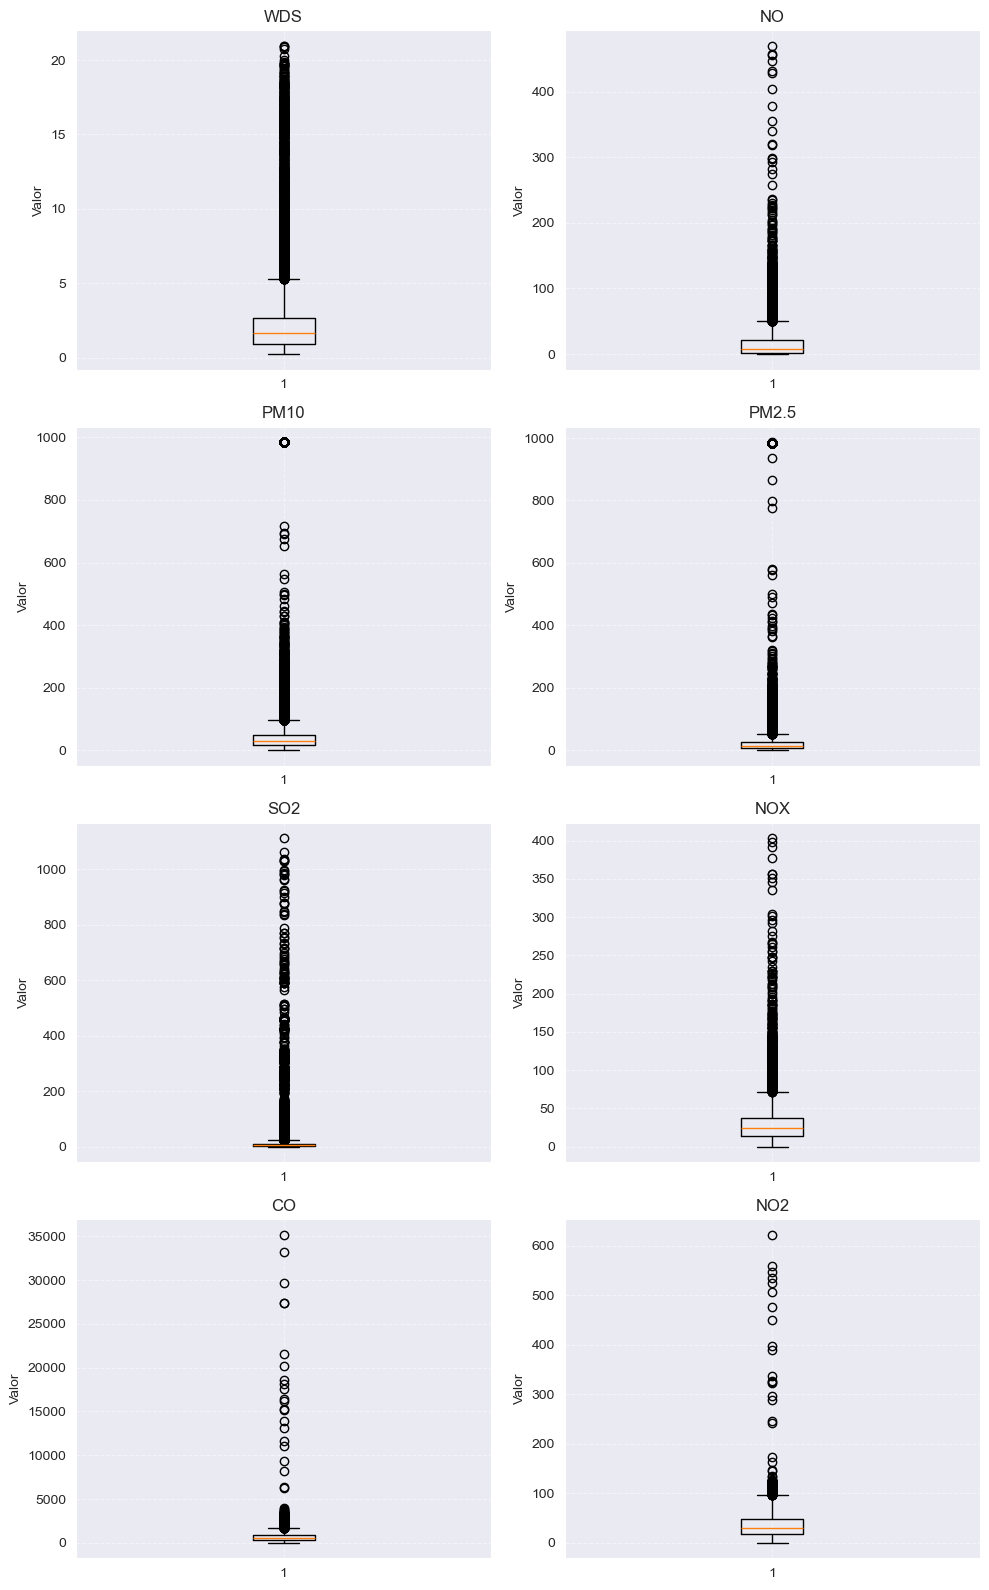

In [18]:
# Valores únicos
variables = df["variable"].unique()
n_vars = len(variables)

# Calcula el número de filas y columnas del grid (ajústalo si prefieres otro layout)
n_cols = 2  # puedes cambiar a 2 o 4 según cuántos plots quieras por fila
n_rows = -(-n_vars // n_cols)  # división entera redondeada hacia arriba

# Crear figura y ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

# Iterar sobre cada variable
for i, var in enumerate(variables):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]
    subset = df[df["variable"] == var]
    
    ax.boxplot(subset["value"], showfliers=True)
    ax.set_title(var)
    ax.set_ylabel("Valor")
    ax.grid(True, linestyle="--", alpha=0.5)

# Eliminar ejes vacíos (si sobran)
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

Histogramas por variable

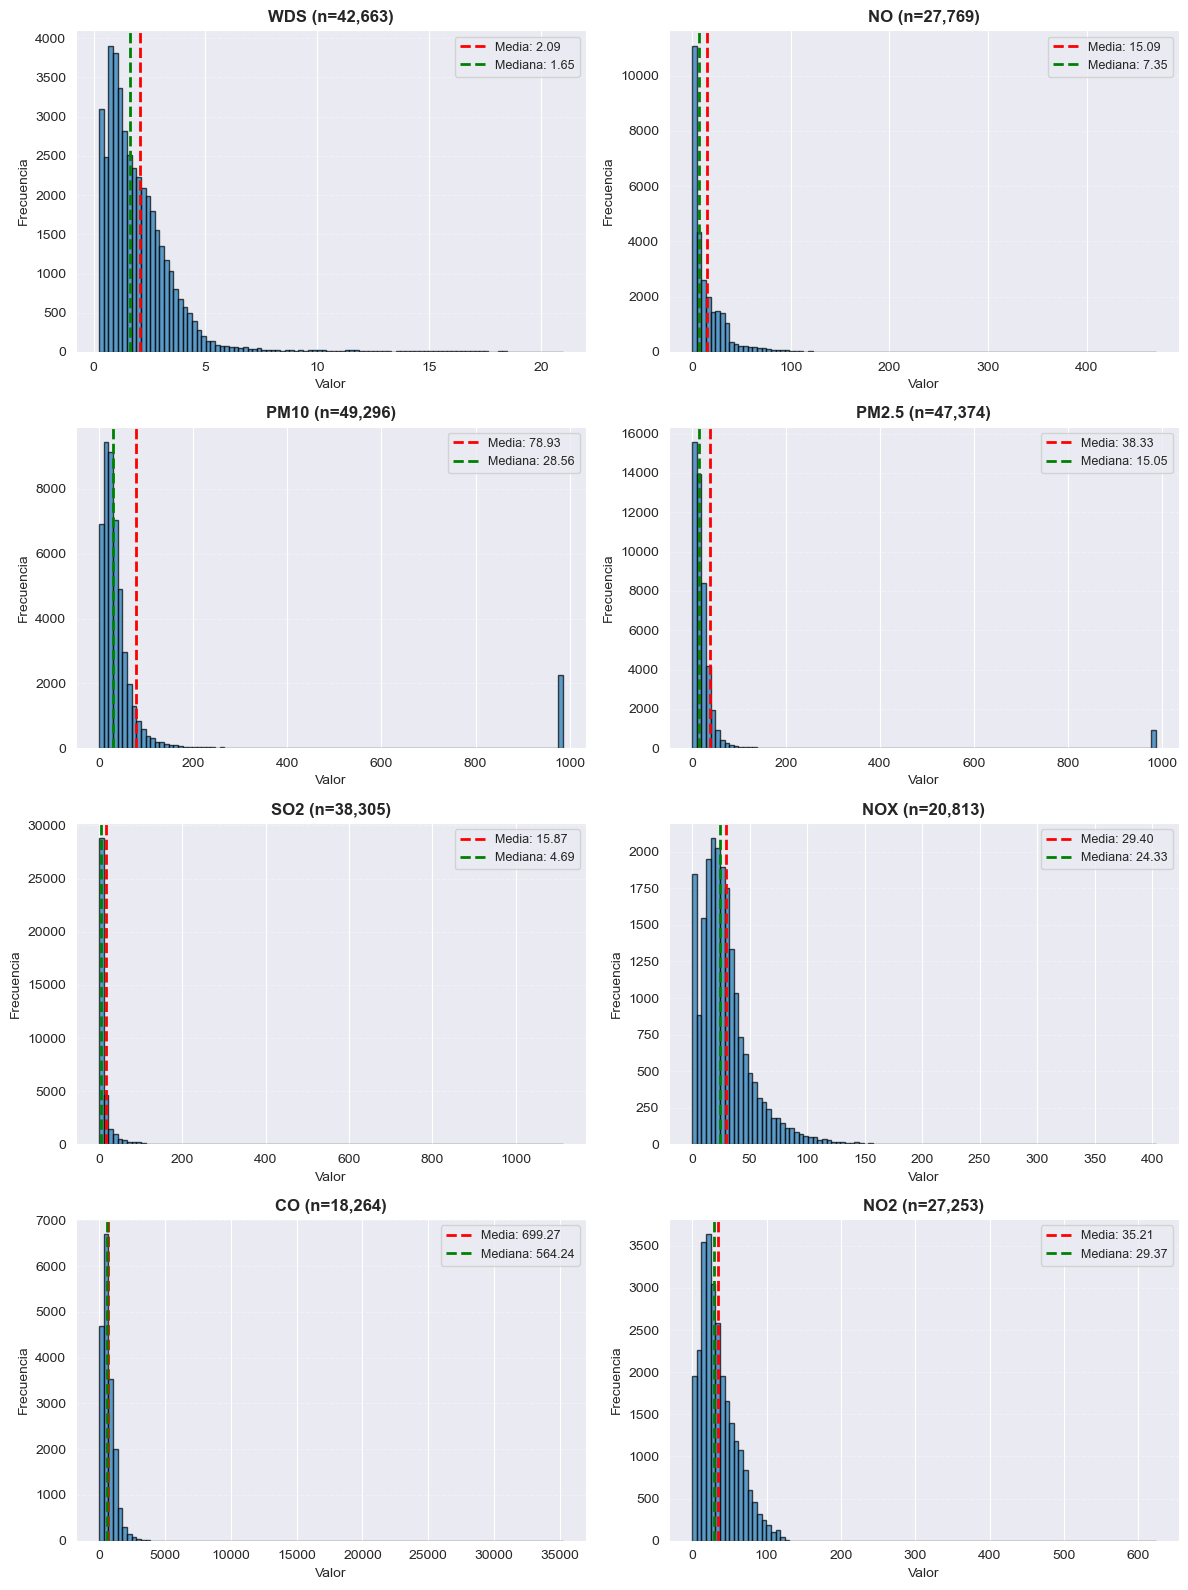

In [19]:
# Valores únicos
variables = df["variable"].unique()
n_vars = len(variables)

# Calcula el número de filas y columnas del grid
n_cols = 2  # puedes cambiar a 3 o 4 según prefieras
n_rows = -(-n_vars // n_cols)  # división entera redondeada hacia arriba

# Crear figura y ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)

# Iterar sobre cada variable
for i, var in enumerate(variables):
    row, col = divmod(i, n_cols)
    ax = axes[row][col]
    subset = df[df["variable"] == var]["value"]

    # Eliminar NaN para evitar warnings
    subset = subset.dropna()
    
    # Crear histograma
    # Puedes ajustar bins='auto', bins=50, o bins=100 según tus datos
    ax.hist(subset, bins=100, edgecolor='black', alpha=0.7)
    
    # Añadir línea vertical de la media y mediana
    ax.axvline(subset.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {subset.mean():.2f}')
    ax.axvline(subset.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {subset.median():.2f}')
    
    ax.set_title(f'{var} (n={len(subset):,})', fontsize=12, fontweight='bold')
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3, axis='y')

# Eliminar ejes vacíos (si sobran)
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

Descripción estadística de las variables

In [20]:
df.groupby("variable")["value"].describe()

,count,mean,std,min,25%,50%,75%,max
variable,,,,,,,,
CO,18264.0,699.274818,808.094387,0.360373,347.001922,564.243439,894.345703,35207.179688
NO,27769.0,15.086976,22.099289,0.000000,2.127919,7.353733,21.295252,469.921997
NO2,27253.0,35.205603,26.401150,0.000000,17.053673,29.374662,49.084282,623.180725
NOX,20813.0,29.396010,25.727911,0.000000,14.131670,24.330210,37.268130,403.039200
PM10,49296.0,78.934076,201.740879,0.000000,15.672712,28.559915,48.018105,985.000000
PM2.5,47374.0,38.329514,134.660825,0.000000,7.667540,15.050390,26.055595,987.266100
SO2,38305.0,15.869294,50.997118,0.000000,2.242745,4.688097,11.037456,1112.700439
WDS,42663.0,2.091577,1.940635,0.254444,0.938611,1.645833,2.683889,20.958240


In [21]:
# Define los percentiles deseados
percentiles = [0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99, 1.00]

# Calcula los percentiles por variable
percentiles_df = df.groupby("variable")["value"].quantile(percentiles).unstack()

# Renombra las columnas para que sean más legibles
percentiles_df.columns = [f'{int(p*100)}' for p in percentiles_df.columns]

# Transponer para tener variables como columnas
percentiles_df = percentiles_df.T

percentiles_df

variable,CO,NO,NO2,NOX,PM10,PM2.5,SO2,WDS
0,0.360373,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.254444
1,42.496397,0.000000,0.000000,0.000000,0.026266,0.000000,0.147167,0.300000
5,146.585241,0.000000,0.037342,0.000000,4.382672,2.432243,0.515475,0.303403
10,212.037161,0.000000,9.227037,5.779384,8.133151,3.944990,0.912883,0.583056
20,306.846894,1.395308,14.707832,11.819290,13.056100,6.224352,1.780334,0.826833
30,385.126541,2.881867,19.337676,16.158180,18.085215,9.000000,2.636616,1.053194
40,466.671698,4.714818,23.997177,20.156606,23.153700,11.976972,3.451037,1.316639
50,564.243439,7.353733,29.374662,24.330210,28.559915,15.050390,4.688097,1.645833
60,675.626709,11.414503,35.562784,28.808840,34.878320,18.776954,6.583598,2.025427
70,812.313855,17.364809,43.980195,33.896146,43.000000,23.351378,9.234874,2.448528


Hacer reporte

In [22]:
reporte = ProfileReport(df)
reporte.to_file("archivos_generados/Reporte perfilamiento - Dataset 3 Final.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:01<00:00,  3.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Exportar a CSV

In [23]:
df.to_csv('../data/preparada/measurements.csv', index=False)